
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [38]:

import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver



## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [39]:

# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 6
GRID_SIZE = 220
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=1.5,
    T_stop=0.5,
    n_steps=200,
    nfreq=10,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1,
    min_substep_fraction=0.1,
    channel_divergence_threshold=1e5,
    eigenvalue_threshold=1e5,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
    diagnosis_Qs = [np.array([0.0, 0.0]), np.pi * np.array([-0.5, -np.sqrt(3)/2]), np.pi * np.array([ 1.0,  0.0]), np.pi * np.array([-0.5,  np.sqrt(3)/2])]
)


## 2. Build the standard spinful kagome model and the two spin patchsets

In [40]:

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

def build_patchsets(model, mu=0.0, npatch=12, grid_size=220, contour_min_points=40):
    patch_up = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=UP_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=DN_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    return {"up": patch_up, "dn": patch_dn}

patchsets = build_patchsets(
    model,
    mu=MU,
    npatch=NPATCH,
    grid_size=GRID_SIZE,
    contour_min_points=CONTOUR_MIN_POINTS,
)

print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)


Patch counts: {'up': 6, 'dn': 6}
mu used for contour (up/dn): 0.0005 0.0005
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16


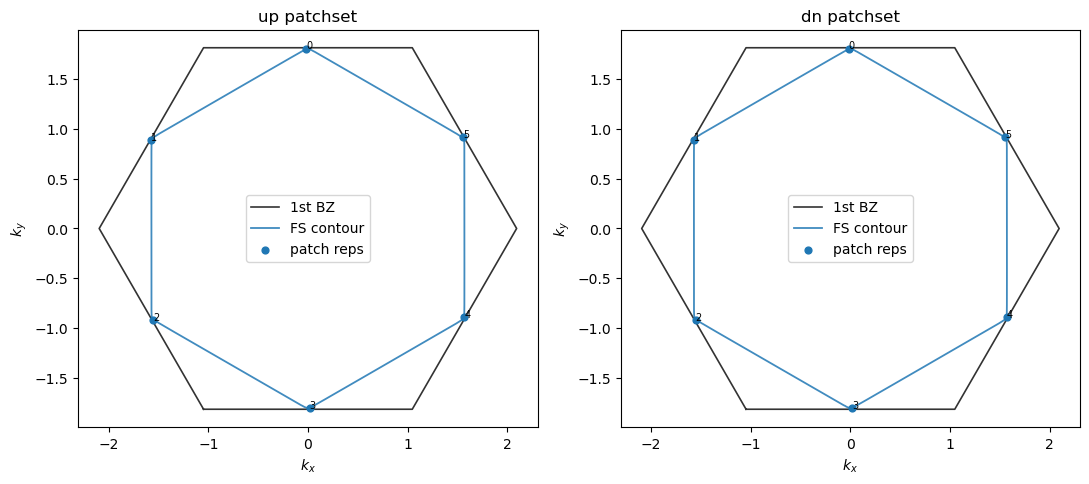

In [41]:

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_patchset(patchsets["up"], ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title("up patchset")
plot_patchset(patchsets["dn"], ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title("dn patchset")
plt.tight_layout()
plt.show()


## 3. Helpers for running a benchmark interaction point

### Debug FRG Solver

In [7]:
from frg_flow import FRGFlowSolver

_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}"
        )
        return rec
    except Exception as e:
        print(f"[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    # print("[DEBUG] temperature path:")
    # for i, T in enumerate(self.temperature_path):
    #     print(f"  i={i:03d}, T={float(T):.8f}")
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run

In [8]:
def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "leading_channel": rec.leading_channel_name,
            "leading_order": rec.leading_order_label,
            "leading_abs_eval": rec.leading_eigenvalue_abs,
            "instability": rec.instability,
            "reason": rec.instability_reason,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    evals = [np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs for h in history]
    norms = [h.channel_norm for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(steps, evals, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("leading |eigenvalue|")
    axes[0].set_title(f"{title}: leading eigenvalue")

    axes[1].plot(steps, norms, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("channel norm")
    axes[1].set_title(f"{title}: channel norm")

    plt.tight_layout()
    plt.show()


def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")
    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )
    history = solver.run()
    print(f"history length = {len(history)}")
    print(f"instability record = {None if solver.instability_record is None else solver.instability_record.step_index}")
    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)
    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }



## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=6.0, V=0.0) =====
[DEBUG] entering step: T_old=1.50000000, dT=-8.25818085e-03
[DEBUG] leaving step: T_new=1.49174182, rhs_norm=15.673445829869177, channel_norm=0.1294341502451542, accepted_substeps=1, max_rel_update=0.021584512526291184
[DEBUG] entering step: T_old=1.49174182, dT=-8.21271582e-03
[DEBUG] leaving step: T_new=1.48352910, rhs_norm=16.18913920557003, channel_norm=0.2623879501819052, accepted_substeps=1, max_rel_update=0.022171951543611304
[DEBUG] entering step: T_old=1.48352910, dT=-8.16750109e-03
[DEBUG] leaving step: T_new=1.47536160, rhs_norm=16.717105341268848, channel_norm=0.3989248462666475, accepted_substeps=1, max_rel_update=0.022768983806333125
[DEBUG] entering step: T_old=1.47536160, dT=-8.12253529e-03
[DEBUG] leaving step: T_new=1.46723907, rhs_norm=17.258086617416772, channel_norm=0.5391042635450822, accepted_substeps=1, max_rel_update=0.02337639941939326
[DEBUG] entering step: T_old=1.46723907, dT=-8.07781705e-03
[DEBUG] lea

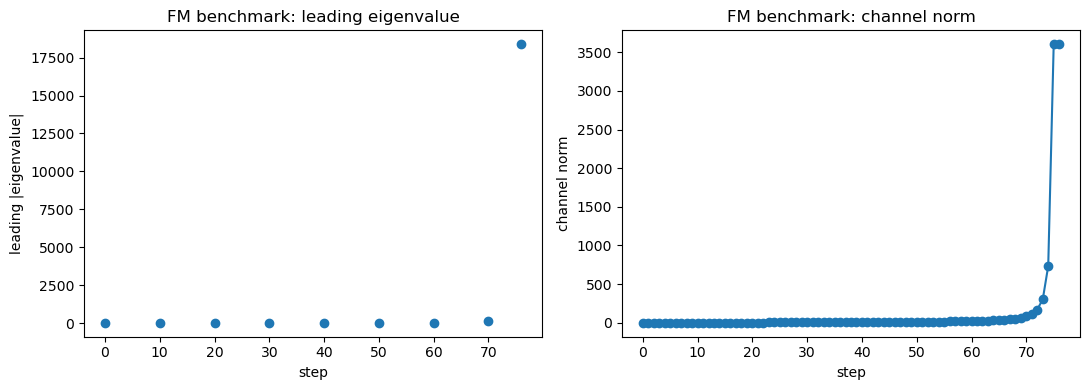

In [7]:

fm_result = run_case("FM benchmark", U=6.0, V=0.0, flow_kwargs=FLOW_KWARGS)



==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 18379.174893856598
vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
vec.abs  = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5888.053764214001
vec.real = [ 7.07111730e-01  1.55302902e-06  2.37187541e-04 -7.07101753e-01
 -1.55214591e-06 -2.37475159e-04]
vec.abs  = [7.07111730e-01 1.55302902e-06 2.37187541e-04 7.07101753e-01
 1.55214591e-06 2.37475159e-04]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 10008.572110478563
vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
vec.abs  = [7.07060035e-01 3.21832580e-04 2.19984888e-04 7.07153310e-01
 3.21513864e-04 2.19953149e-04]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 5900.842538485015
vec.real = [-7.07066422e-01 -3.75107687e-04  4.56785480e-04  7.07146644e-01
  3.75225156e-04 -4.57017143e-04]
vec.abs  = [7.070664

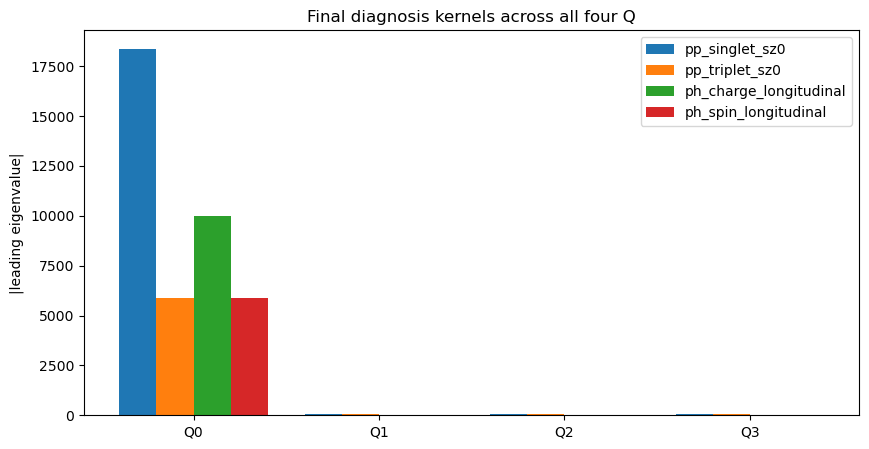


==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 18379.174893856598
vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
vec.abs  = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5888.053764214001
vec.real = [ 7.07111730e-01  1.55302902e-06  2.37187541e-04 -7.07101753e-01
 -1.55214591e-06 -2.37475159e-04]
vec.abs  = [7.07111730e-01 1.55302902e-06 2.37187541e-04 7.07101753e-01
 1.55214591e-06 2.37475159e-04]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 10008.572110478563
vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
vec.abs  = [7.07060035e-01 3.21832580e-04 2.19984888e-04 7.07153310e-01
 3.21513864e-04 2.19953149e-04]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 5900.842538485015
vec.real = [-7.07066422e-01 -3.75107687e-04  4.56785480e-04  7.07146644e-01
  3.75225156e-04 -4.57017143e-04]
vec.abs  = [7.070664

In [22]:

solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]

channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = fm_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

### Debug: Patch succeptibility

In [20]:
# ============================================================
# Patch-scaling test built on THIS notebook's actual pipeline
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

from noninteracting import KagomeNagaosa
from patching import FSPatcher
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
from frg_kernel import FlowConfig, compute_pp_kernel_fast, compute_ph_kernel_fast
from channels import ChannelKernel


# ------------------------------------------------------------
# 0. Use notebook globals if they already exist; otherwise fallback
# ------------------------------------------------------------
try:
    MODEL_PARAMS
except NameError:
    MODEL_PARAMS = dict(t=1.0, phi=0.0)

try:
    MU
except NameError:
    MU = 0.0

try:
    GRID_SIZE
except NameError:
    GRID_SIZE = 220

try:
    CONTOUR_MIN_POINTS
except NameError:
    CONTOUR_MIN_POINTS = 40

try:
    UP_SLICE
except NameError:
    UP_SLICE = slice(0, 3)

try:
    DN_SLICE
except NameError:
    DN_SLICE = slice(3, 6)

try:
    LOCAL_BAND_INDEX
except NameError:
    LOCAL_BAND_INDEX = 1

try:
    FLOW_KWARGS
except NameError:
    FLOW_KWARGS = dict(
        T_start=1.5,
        T_stop=0.5,
        n_steps=200,
        nfreq=10,
        diagnose_every=10,
        temperature_grid="log",
        include_explicit_T_prefactor=True,
        max_relative_update=1,
        min_substep_fraction=0.1,
        channel_divergence_threshold=1e5,
        eigenvalue_threshold=1e5,
        diagnosis_sort_by="abs",
        track_crossed_channel=True,
        diagnosis_Qs=[
            np.array([0.0, 0.0]),
            np.pi * np.array([-0.5, -np.sqrt(3)/2]),
            np.pi * np.array([ 1.0,  0.0]),
            np.pi * np.array([-0.5,  np.sqrt(3)/2]),
        ],
    )


# ------------------------------------------------------------
# 1. Basic helpers
# ------------------------------------------------------------
def _leading_abs_eig(kernel, sort_by="abs"):
    vals, vecs = kernel.eig(sort_by=sort_by)
    return float(np.abs(vals[0])), vals[0], vecs[:, 0]


def _kernel_template_info(kernel, sort_by="abs"):
    lead_abs, lead_val, lead_vec = _leading_abs_eig(kernel, sort_by=sort_by)
    return {
        "leading_abs": lead_abs,
        "leading_val": lead_val,
        "leading_vec_real": np.real(lead_vec),
        "leading_vec_abs": np.abs(lead_vec),
    }


def _safe_ratio(num, den):
    den = float(den)
    if abs(den) < 1e-14:
        return np.nan
    return float(num) / den


# ------------------------------------------------------------
# 2. Build model / patchsets / solver exactly like your notebook
# ------------------------------------------------------------
def build_model():
    return KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)


def build_patchsets_for_npatch(
    npatch,
    *,
    mu=MU,
    grid_size=GRID_SIZE,
    contour_min_points=CONTOUR_MIN_POINTS,
):
    model = build_model()

    patch_up = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=UP_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=DN_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
    ).build()

    patchsets = {"up": patch_up, "dn": patch_dn}
    return model, patchsets


def build_interaction(model, U, V):
    return BareExtendedHubbard.from_kagome_model(model, U=U, V=V)


def build_solver_for_patchsets(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = dict(FLOW_KWARGS if flow_kwargs is None else flow_kwargs)
    interaction = build_interaction(model, U, V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


# ------------------------------------------------------------
# 3. Longitudinal / singlet combination helpers
#    (copied from your own notebook logic, but made reusable)
# ------------------------------------------------------------
def combine_pp_singlet_triplet(K_ud_ud, K_ud_du, K_du_ud, K_du_du, Q):
    singlet = 0.5 * (
        K_ud_ud.matrix - K_ud_du.matrix - K_du_ud.matrix + K_du_du.matrix
    )
    triplet = 0.5 * (
        K_ud_ud.matrix + K_ud_du.matrix + K_du_ud.matrix + K_du_du.matrix
    )

    template = K_ud_ud
    K_singlet = ChannelKernel(
        name="pp_singlet_sz0",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(singlet, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("S", "S"),
        col_spins=("S", "S"),
        residuals=template.residuals.copy(),
    )
    K_triplet = ChannelKernel(
        name="pp_triplet_sz0",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(triplet, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("T", "T"),
        col_spins=("T", "T"),
        residuals=template.residuals.copy(),
    )
    return K_singlet, K_triplet


def combine_ph_longitudinal(K_uu_uu, K_uu_dd, K_dd_uu, K_dd_dd, Q):
    charge = 0.5 * (
        K_uu_uu.matrix + K_uu_dd.matrix + K_dd_uu.matrix + K_dd_dd.matrix
    )
    spin = 0.5 * (
        K_uu_uu.matrix - K_uu_dd.matrix - K_dd_uu.matrix + K_dd_dd.matrix
    )

    residuals = np.maximum.reduce([
        K_uu_uu.residuals,
        K_uu_dd.residuals,
        K_dd_uu.residuals,
        K_dd_dd.residuals,
    ])

    template = K_uu_uu
    K_charge = ChannelKernel(
        name="ph_charge_longitudinal",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(charge, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("rho", "rho"),
        col_spins=("rho", "rho"),
        residuals=np.asarray(residuals, dtype=float),
    )
    K_spin = ChannelKernel(
        name="ph_spin_longitudinal",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(spin, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("sz", "sz"),
        col_spins=("sz", "sz"),
        residuals=np.asarray(residuals, dtype=float),
    )
    return K_charge, K_spin


# ------------------------------------------------------------
# 4. Bare RHS kernels at a given Q and T
# ------------------------------------------------------------
def build_bare_rhs_kernels_for_patchsets(patchsets, model, U, V, Q, T, flow_kwargs=None):
    interaction, bare_gamma, solver0 = build_solver_for_patchsets(
        model, patchsets, U, V, flow_kwargs=flow_kwargs
    )

    cfg = FlowConfig(
        temperature=float(T),
        nfreq=solver0.nfreq,
        include_explicit_T_prefactor=solver0.include_explicit_T_prefactor,
    )

    # ----- raw pp -----
    K_ud_ud = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "dn"),
        outgoing_spins=("up", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_ud_du = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "dn"),
        outgoing_spins=("dn", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_du_ud = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "up"),
        outgoing_spins=("up", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_du_du = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "up"),
        outgoing_spins=("dn", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_pp_singlet, K_pp_triplet = combine_pp_singlet_triplet(
        K_ud_ud, K_ud_du, K_du_ud, K_du_du, Q
    )

    # ----- raw longitudinal ph -----
    K_uu_uu = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "up"),
        outgoing_spins=("up", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_uu_dd = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "up"),
        outgoing_spins=("dn", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_dd_uu = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "dn"),
        outgoing_spins=("up", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_dd_dd = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "dn"),
        outgoing_spins=("dn", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_ph_charge, K_ph_spin = combine_ph_longitudinal(
        K_uu_uu, K_uu_dd, K_dd_uu, K_dd_dd, Q
    )

    kernels = {
        "rhs_pp_singlet_sz0": K_pp_singlet,
        "rhs_pp_triplet_sz0": K_pp_triplet,
        "rhs_ph_charge_longitudinal": K_ph_charge,
        "rhs_ph_spin_longitudinal": K_ph_spin,
        # raw blocks if later needed
        "rhs_pp_ud_to_ud": K_ud_ud,
        "rhs_pp_ud_to_du": K_ud_du,
        "rhs_pp_du_to_ud": K_du_ud,
        "rhs_pp_du_to_du": K_du_du,
        "rhs_ph_uu_to_uu": K_uu_uu,
        "rhs_ph_uu_to_dd": K_uu_dd,
        "rhs_ph_dd_to_uu": K_dd_uu,
        "rhs_ph_dd_to_dd": K_dd_dd,
    }

    return {
        "interaction": interaction,
        "bare_gamma": bare_gamma,
        "solver0": solver0,
        "Q": np.asarray(Q, dtype=float),
        "T": float(T),
        "kernels": kernels,
    }


# ------------------------------------------------------------
# 5. Stage evaluators
# ------------------------------------------------------------
def evaluate_bare_stage(solver, Qs):
    out = {}
    for Q in Qs:
        Qkey = tuple(np.round(Q, 8))
        kernels = solver.build_diagnosis_kernel_dict(np.asarray(Q, dtype=float))
        out[Qkey] = {
            "pp_singlet_sz0": _kernel_template_info(kernels["pp_singlet_sz0"]),
            "ph_charge_longitudinal": _kernel_template_info(kernels["ph_charge_longitudinal"]),
            "ph_spin_longitudinal": _kernel_template_info(kernels["ph_spin_longitudinal"]),
        }
    return out


def evaluate_rhs_stage(patchsets, model, U, V, Qs, T_rhs, flow_kwargs=None):
    out = {}
    for Q in Qs:
        Q = np.asarray(Q, dtype=float)
        Qkey = tuple(np.round(Q, 8))
        rhs = build_bare_rhs_kernels_for_patchsets(
            patchsets, model, U, V, Q=Q, T=T_rhs, flow_kwargs=flow_kwargs
        )
        kernels = rhs["kernels"]
        out[Qkey] = {
            "pp_singlet_sz0": _kernel_template_info(kernels["rhs_pp_singlet_sz0"]),
            "ph_charge_longitudinal": _kernel_template_info(kernels["rhs_ph_charge_longitudinal"]),
            "ph_spin_longitudinal": _kernel_template_info(kernels["rhs_ph_spin_longitudinal"]),
        }
    return out


def evaluate_flow_stage(solver, Qs):
    out = {}
    for Q in Qs:
        Qkey = tuple(np.round(Q, 8))
        kernels = solver.build_diagnosis_kernel_dict(np.asarray(Q, dtype=float))
        out[Qkey] = {
            "pp_singlet_sz0": _kernel_template_info(kernels["pp_singlet_sz0"]),
            "ph_charge_longitudinal": _kernel_template_info(kernels["ph_charge_longitudinal"]),
            "ph_spin_longitudinal": _kernel_template_info(kernels["ph_spin_longitudinal"]),
        }
    return out


# ------------------------------------------------------------
# 6. Q=0 extractor + metrics
# ------------------------------------------------------------
def summarize_stage_over_Q(stage_dict):
    keys = list(stage_dict.keys())
    q0_key = None
    for k in keys:
        if np.linalg.norm(np.array(k, dtype=float)) < 1e-8:
            q0_key = k
            break
    if q0_key is None:
        raise ValueError("No Q=0 entry found in stage_dict.")

    q0 = stage_dict[q0_key]
    others = {k: v for k, v in stage_dict.items() if k != q0_key}

    pp0 = q0["pp_singlet_sz0"]["leading_abs"]
    phc0 = q0["ph_charge_longitudinal"]["leading_abs"]
    phs0 = q0["ph_spin_longitudinal"]["leading_abs"]

    phs_max_nonzeroQ = np.nan
    if len(others) > 0:
        phs_max_nonzeroQ = max(v["ph_spin_longitudinal"]["leading_abs"] for v in others.values())

    return {
        "Q0_pp": pp0,
        "Q0_ph_charge": phc0,
        "Q0_ph_spin": phs0,
        "R_spin": _safe_ratio(phs0, pp0),
        "R_charge": _safe_ratio(phc0, pp0),
        "Q0_over_max_nonzeroQ_ph_spin": _safe_ratio(phs0, phs_max_nonzeroQ) if len(others) > 0 else np.nan,
        "full": stage_dict,
    }


# ------------------------------------------------------------
# 7. Main patch-scaling driver
# ------------------------------------------------------------
def run_patch_scaling_test(
    patch_list,
    *,
    U=6.0,
    V=0.0,
    Qs=None,
    flow_kwargs=None,
    run_flow=True,
    verbose=True,
):
    if Qs is None:
        Qs = list(FLOW_KWARGS["diagnosis_Qs"])
    if flow_kwargs is None:
        flow_kwargs = dict(FLOW_KWARGS)

    results = []

    for npatch in patch_list:
        if verbose:
            print(f"\n===== Npatch = {npatch} =====")

        model, patchsets = build_patchsets_for_npatch(
            npatch,
            mu=MU,
            grid_size=GRID_SIZE,
            contour_min_points=CONTOUR_MIN_POINTS,
        )

        if verbose:
            print("patch counts:", {k: v.Npatch for k, v in patchsets.items()})
            print(
                "mu_used_for_contour (up/dn):",
                patchsets["up"].mu_used_for_contour,
                patchsets["dn"].mu_used_for_contour,
            )

        interaction, bare_gamma, solver0 = build_solver_for_patchsets(
            model, patchsets, U, V, flow_kwargs=flow_kwargs
        )

        # ----- bare -----
        bare_full = evaluate_bare_stage(solver0, Qs)
        bare_summary = summarize_stage_over_Q(bare_full)

        # ----- RHS at initial T -----
        T_rhs = float(flow_kwargs["T_start"])
        rhs_full = evaluate_rhs_stage(
            patchsets, model, U, V, Qs, T_rhs=T_rhs, flow_kwargs=flow_kwargs
        )
        rhs_summary = summarize_stage_over_Q(rhs_full)

        # ----- flow -----
        flow_summary = None
        final_record = None
        solver = None
        if run_flow:
            interaction, bare_gamma, solver = build_solver_for_patchsets(
                model, patchsets, U, V, flow_kwargs=flow_kwargs
            )
            solver.run()
            flow_full = evaluate_flow_stage(solver, Qs)
            flow_summary = summarize_stage_over_Q(flow_full)
            final_record = solver.history[-1].summary_dict() if len(solver.history) else None

        row = {
            "Npatch": int(npatch),
            "patchsets": patchsets,
            "model": model,
            "interaction": interaction,
            "bare_solver": solver0,
            "flow_solver": solver,
            "bare": bare_summary,
            "rhs": rhs_summary,
            "flow": flow_summary,
            "final_record": final_record,
        }
        results.append(row)

        if verbose:
            print(
                f"[bare] R_spin={bare_summary['R_spin']:.6g}, "
                f"R_charge={bare_summary['R_charge']:.6g}, "
                f"Q0/maxQ(ph_spin)={bare_summary['Q0_over_max_nonzeroQ_ph_spin']:.6g}"
            )
            print(
                f"[rhs ] R_spin={rhs_summary['R_spin']:.6g}, "
                f"R_charge={rhs_summary['R_charge']:.6g}, "
                f"Q0/maxQ(ph_spin)={rhs_summary['Q0_over_max_nonzeroQ_ph_spin']:.6g}"
            )
            if flow_summary is not None:
                print(
                    f"[flow] R_spin={flow_summary['R_spin']:.6g}, "
                    f"R_charge={flow_summary['R_charge']:.6g}, "
                    f"Q0/maxQ(ph_spin)={flow_summary['Q0_over_max_nonzeroQ_ph_spin']:.6g}"
                )
                if final_record is not None:
                    print(
                        f"       final leading channel = {final_record.get('leading_channel_name', None)} | "
                        f"leading order = {final_record.get('leading_order_label', None)} | "
                        f"leading |eig| = {final_record.get('leading_eigenvalue_abs', None)}"
                    )

    return results


# ------------------------------------------------------------
# 8. Plot helper
# ------------------------------------------------------------
def plot_patch_scaling_results(results):
    N = [r["Npatch"] for r in results]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # --- ratios ---
    axes[0].plot(N, [r["bare"]["R_spin"] for r in results], "o-", label="bare: ph_spin / pp")
    axes[0].plot(N, [r["rhs"]["R_spin"] for r in results], "s-", label="rhs: ph_spin / pp")
    if results[0]["flow"] is not None:
        axes[0].plot(N, [r["flow"]["R_spin"] for r in results], "^-", label="flow: ph_spin / pp")
    axes[0].set_xlabel("Npatch")
    axes[0].set_ylabel("R_spin")
    axes[0].set_title("Spin / PP ratio")
    axes[0].grid(True)
    axes[0].legend()

    # --- charge ratios ---
    axes[1].plot(N, [r["bare"]["R_charge"] for r in results], "o-", label="bare: ph_charge / pp")
    axes[1].plot(N, [r["rhs"]["R_charge"] for r in results], "s-", label="rhs: ph_charge / pp")
    if results[0]["flow"] is not None:
        axes[1].plot(N, [r["flow"]["R_charge"] for r in results], "^-", label="flow: ph_charge / pp")
    axes[1].set_xlabel("Npatch")
    axes[1].set_ylabel("R_charge")
    axes[1].set_title("Charge / PP ratio")
    axes[1].grid(True)
    axes[1].legend()

    # --- Q=0 dominance in ph_spin ---
    axes[2].plot(N, [r["bare"]["Q0_over_max_nonzeroQ_ph_spin"] for r in results], "o-", label="bare")
    axes[2].plot(N, [r["rhs"]["Q0_over_max_nonzeroQ_ph_spin"] for r in results], "s-", label="rhs")
    if results[0]["flow"] is not None:
        axes[2].plot(N, [r["flow"]["Q0_over_max_nonzeroQ_ph_spin"] for r in results], "^-", label="flow")
    axes[2].axhline(1.0, ls="--", lw=1.0, color="gray")
    axes[2].set_xlabel("Npatch")
    axes[2].set_ylabel("Q0 / max(nonzero Q)")
    axes[2].set_title("Q=0 dominance of ph_spin")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. Compact table printer
# ------------------------------------------------------------
def print_patch_scaling_table(results):
    print("\n================ PATCH SCALING SUMMARY ================\n")
    header = (
        f"{'Np':>4s} | "
        f"{'bare Rspin':>12s} {'rhs Rspin':>12s} {'flow Rspin':>12s} | "
        f"{'bare Rchg':>12s} {'rhs Rchg':>12s} {'flow Rchg':>12s}"
    )
    print(header)
    print("-" * len(header))

    for r in results:
        npatch = r["Npatch"]
        flow_rspin = np.nan if r["flow"] is None else r["flow"]["R_spin"]
        flow_rchg = np.nan if r["flow"] is None else r["flow"]["R_charge"]

        print(
            f"{npatch:4d} | "
            f"{r['bare']['R_spin']:12.6g} {r['rhs']['R_spin']:12.6g} {flow_rspin:12.6g} | "
            f"{r['bare']['R_charge']:12.6g} {r['rhs']['R_charge']:12.6g} {flow_rchg:12.6g}"
        )


===== Npatch = 6 =====
patch counts: {'up': 6, 'dn': 6}
mu_used_for_contour (up/dn): 0.0005 0.0005
[DEBUG] entering step: T_old=1.50000000, dT=-8.25818085e-03
[DEBUG] leaving step: T_new=1.49174182, rhs_norm=15.673445829869177, channel_norm=0.1294341502451542, accepted_substeps=1, max_rel_update=0.021584512526291184
[DEBUG] entering step: T_old=1.49174182, dT=-8.21271582e-03
[DEBUG] leaving step: T_new=1.48352910, rhs_norm=16.18913920557003, channel_norm=0.2623879501819052, accepted_substeps=1, max_rel_update=0.022171951543611304
[DEBUG] entering step: T_old=1.48352910, dT=-8.16750109e-03
[DEBUG] leaving step: T_new=1.47536160, rhs_norm=16.717105341268848, channel_norm=0.3989248462666475, accepted_substeps=1, max_rel_update=0.022768983806333125
[DEBUG] entering step: T_old=1.47536160, dT=-8.12253529e-03
[DEBUG] leaving step: T_new=1.46723907, rhs_norm=17.258086617416772, channel_norm=0.5391042635450822, accepted_substeps=1, max_rel_update=0.02337639941939326
[DEBUG] entering step: T_o

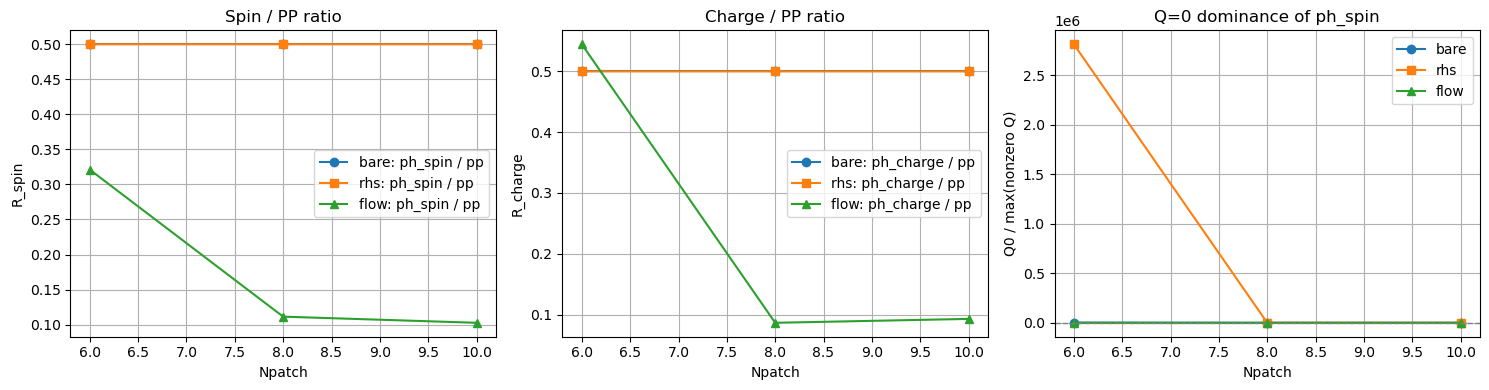


===== Final record | Npatch = 6 =====
{'accepted_substeps': 0,
 'channel_norm': 3603.1919258683533,
 'dT': -0.00545839325040387,
 'diagnosis_payload': {'Q': [0.0, 0.0],
                       'channel_sector': 'pp',
                       'coarse_label': 'pp_even',
                       'coarse_score': 0.9999999969214963,
                       'degeneracy': 1,
                       'internal_mode': {'channel_sector': 'pp',
                                         'dominant_pair': (0, 1),
                                         'inter_sublattice_weight': 0.9999999999999999,
                                         'leg_spin_structure': ('up', 'dn'),
                                         'pair_weights': [[0.0,
                                                           0.18413530970812336,
                                                           0.1771861603525979],
                                                          [0.18413530970812336,
                                  

In [22]:
# ==========================================
# Run the patch-scaling test for FM benchmark
# ==========================================

patch_list = [6, 8, 10]

results_patch_scaling = run_patch_scaling_test(
    patch_list,
    U=6.0,
    V=0.0,              # 若你想测最近那组参数，可改成 V=0.2
    Qs=FLOW_KWARGS["diagnosis_Qs"],
    flow_kwargs=FLOW_KWARGS,
    run_flow=True,      # 先直接全跑；若太慢可改 False
    verbose=True,
)

print_patch_scaling_table(results_patch_scaling)
plot_patch_scaling_results(results_patch_scaling)


# -------------------------------------------------
# Optional: inspect final flow record for each patch
# -------------------------------------------------
for row in results_patch_scaling:
    print(f"\n===== Final record | Npatch = {row['Npatch']} =====")
    pprint(row["final_record"])

In [28]:
# ============================================================
# Bare-level sublattice-interference test at exact M points
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

from noninteracting import KagomeNagaosa
from interaction import BareExtendedHubbard


# ------------------------------------------------------------
# 0. notebook globals fallback
# ------------------------------------------------------------
try:
    MODEL_PARAMS
except NameError:
    MODEL_PARAMS = dict(t=1.0, phi=0.0)

try:
    UP_SLICE
except NameError:
    UP_SLICE = slice(0, 3)

try:
    DN_SLICE
except NameError:
    DN_SLICE = slice(3, 6)

try:
    LOCAL_BAND_INDEX
except NameError:
    LOCAL_BAND_INDEX = 1


# ------------------------------------------------------------
# 1. model helpers
# ------------------------------------------------------------
def build_spinful_model_for_interference():
    return KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)


def sector_eigvec(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm < 1e-14:
        raise ValueError("Zero-norm eigenvector encountered.")
    return u / nrm, float(evals[band_index])


def dominant_sublattice_label(u):
    idx = int(np.argmax(np.abs(u) ** 2))
    return ["A", "B", "C"][idx]


def orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex)) ** 2
    return w / np.sum(w)


# ------------------------------------------------------------
# 2. exact M-point set (6 points)
#    We use ±M1, ±M2, ±M3 with
#      M1 = b1/2, M2 = b2/2, M3 = (b1+b2)/2
# ------------------------------------------------------------
def six_M_points(model):
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    M1 = 0.5 * b1
    M2 = 0.5 * b2
    M3 = 0.5 * (b1 + b2)

    pts = np.array([
        +M1, +M2, +M3,
        -M1, -M2, -M3,
    ], dtype=float)

    # sort by polar angle for prettier plots / tables
    ang = np.arctan2(pts[:, 1], pts[:, 0])
    order = np.argsort(ang)
    return pts[order]


# ------------------------------------------------------------
# 3. PRL nesting vectors already used in your notebook
# ------------------------------------------------------------
def prl_nesting_vectors():
    return {
        "Q1": np.pi * np.array([-0.5, -np.sqrt(3)/2], dtype=float),
        "Q2": np.pi * np.array([ 1.0,  0.0], dtype=float),
        "Q3": np.pi * np.array([-0.5,  np.sqrt(3)/2], dtype=float),
        "Q0": np.array([0.0, 0.0], dtype=float),
    }


# ------------------------------------------------------------
# 4. direct "single-line" overlap diagnostic for onsite U
#
# For onsite U only (V=0), one ph line contributes factor
#   F_p(Q) = sum_a |u_a(k+Q)^* u_a(k)|^2
# This is a clean measure of whether k and k+Q live on the
# same sublattice texture or different ones.
# ------------------------------------------------------------
def line_overlap_factor(u_k, u_kq):
    return float(np.sum(np.abs(np.conjugate(u_kq) * u_k) ** 2))


# ------------------------------------------------------------
# 5. full two-line projected direct bare vertex for ph-like process
#
#   (k1,up), (k2,dn) -> (k1+Q,up), (k2-Q,dn)
#
# This obeys momentum conservation exactly and directly probes
# the projected local-U matrix element in band basis.
# ------------------------------------------------------------
def direct_ph_like_vertex(interaction, model, k1, u1, k2, u2, Q, orbital_slice_up, orbital_slice_dn, band_index):
    k3 = np.asarray(k1, dtype=float) + np.asarray(Q, dtype=float)
    k4 = np.asarray(k2, dtype=float) - np.asarray(Q, dtype=float)

    u3, _ = sector_eigvec(model, k3, orbital_slice_up, band_index)
    u4, _ = sector_eigvec(model, k4, orbital_slice_dn, band_index)

    val = interaction.direct_band_vertex(
        k1, u1, "up",
        k2, u2, "dn",
        k3, u3, "up",
        k4, u4, "dn",
        check_momentum=True,
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
    )
    return complex(val), u3, u4


# ------------------------------------------------------------
# 6. main analysis
# ------------------------------------------------------------
def run_sublattice_interference_test(
    *,
    U=6.0,
    V=0,
    band_index=LOCAL_BAND_INDEX,
    orbital_slice_up=UP_SLICE,
    orbital_slice_dn=DN_SLICE,
    verbose=True,
):
    model = build_spinful_model_for_interference()
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)

    ks = six_M_points(model)
    Qs = prl_nesting_vectors()

    # states at the 6 exact M points
    states = []
    for i, k in enumerate(ks):
        u_up, e_up = sector_eigvec(model, k, orbital_slice_up, band_index)
        states.append({
            "id": i,
            "k": k,
            "u_up": u_up,
            "energy": e_up,
            "weight": orbital_weight(u_up),
            "dominant": dominant_sublattice_label(u_up),
        })

    # --- single-line overlap factors F_p(Q)
    line_data = {}
    for qname, Q in Qs.items():
        line_data[qname] = []
        for s in states:
            u_q, _ = sector_eigvec(model, s["k"] + Q, orbital_slice_up, band_index)
            F = line_overlap_factor(s["u_up"], u_q)
            line_data[qname].append({
                "id": s["id"],
                "k": s["k"],
                "Q": Q,
                "dominant_k": s["dominant"],
                "dominant_kQ": dominant_sublattice_label(u_q),
                "F_line": F,
                "w_k": s["weight"],
                "w_kQ": orbital_weight(u_q),
            })

    # --- full two-line direct projected bare vertex matrix
    pair_data = {}
    for qname, Q in Qs.items():
        mat = np.zeros((len(states), len(states)), dtype=complex)
        dom_table = [[None for _ in states] for __ in states]

        for i, si in enumerate(states):
            for j, sj in enumerate(states):
                val, u3, u4 = direct_ph_like_vertex(
                    interaction, model,
                    si["k"], si["u_up"],
                    sj["k"], sj["u_up"],   # spin-down block has same orbital structure when B=None
                    Q,
                    orbital_slice_up, orbital_slice_dn, band_index,
                )
                mat[i, j] = val
                dom_table[i][j] = (
                    si["dominant"],
                    sj["dominant"],
                    dominant_sublattice_label(u3),
                    dominant_sublattice_label(u4),
                )

        pair_data[qname] = {
            "matrix": mat,
            "abs_matrix": np.abs(mat),
            "mean_abs": float(np.mean(np.abs(mat))),
            "max_abs": float(np.max(np.abs(mat))),
            "dominant_labels": dom_table,
        }

    # ratios relative to Q=0
    ref_line = np.array([x["F_line"] for x in line_data["Q0"]], dtype=float)
    line_summary = {}
    for qname in ["Q0", "Q1", "Q2", "Q3"]:
        arr = np.array([x["F_line"] for x in line_data[qname]], dtype=float)
        line_summary[qname] = {
            "mean_F": float(np.mean(arr)),
            "min_F": float(np.min(arr)),
            "max_F": float(np.max(arr)),
            "mean_ratio_to_Q0": float(np.mean(arr / (ref_line + 1e-14))),
        }

    ref_pair = pair_data["Q0"]["mean_abs"]
    pair_summary = {}
    for qname in ["Q0", "Q1", "Q2", "Q3"]:
        pair_summary[qname] = {
            "mean_abs": pair_data[qname]["mean_abs"],
            "max_abs": pair_data[qname]["max_abs"],
            "mean_ratio_to_Q0": pair_data[qname]["mean_abs"] / (ref_pair + 1e-14),
        }

    result = {
        "model": model,
        "interaction": interaction,
        "states": states,
        "line_data": line_data,
        "pair_data": pair_data,
        "line_summary": line_summary,
        "pair_summary": pair_summary,
        "Qs": Qs,
    }

    if verbose:
        print("\n===== Exact M-point states =====")
        for s in states:
            print(
                f"id={s['id']} | k={np.round(s['k'], 6)} | "
                f"E={s['energy']:.8f} | dominant={s['dominant']} | "
                f"w={np.round(s['weight'], 4)}"
            )

        print("\n===== Single-line overlap summary =====")
        pprint(line_summary)

        print("\n===== Full projected direct-vertex summary =====")
        pprint(pair_summary)

    return result


# ------------------------------------------------------------
# 7. plotting
# ------------------------------------------------------------
def plot_sublattice_interference_result(res):
    q_order = ["Q0", "Q1", "Q2", "Q3"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # (a) orbital weights at the 6 M points
    ids = [s["id"] for s in res["states"]]
    wA = [s["weight"][0] for s in res["states"]]
    wB = [s["weight"][1] for s in res["states"]]
    wC = [s["weight"][2] for s in res["states"]]

    x = np.arange(len(ids))
    axes[0].bar(x - 0.25, wA, width=0.25, label="A")
    axes[0].bar(x,         wB, width=0.25, label="B")
    axes[0].bar(x + 0.25, wC, width=0.25, label="C")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([str(i) for i in ids])
    axes[0].set_xlabel("manual M-point id")
    axes[0].set_ylabel("orbital weight")
    axes[0].set_title("Sublattice texture at exact M points")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # (b) single-line overlap suppression
    meanF = [res["line_summary"][q]["mean_F"] for q in q_order]
    axes[1].bar(q_order, meanF)
    axes[1].set_ylabel("mean F_line")
    axes[1].set_title(r"Single-line overlap  $F_p(Q)=\sum_a |u_a(k+Q)^*u_a(k)|^2$")
    axes[1].grid(True, alpha=0.3)

    # (c) full projected direct-vertex suppression
    meanV = [res["pair_summary"][q]["mean_abs"] for q in q_order]
    axes[2].bar(q_order, meanV)
    axes[2].set_ylabel(r"mean $|V_{\rm dir}|$")
    axes[2].set_title("Full projected bare local-U vertex")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_interference_tables(res):
    print("\n================ INTERFERENCE SUMMARY ================\n")

    print("---- Single-line overlap ----")
    print(f"{'Q':>4s} | {'mean F':>12s} {'min F':>12s} {'max F':>12s} {'mean/Q0':>12s}")
    print("-" * 62)
    for q in ["Q0", "Q1", "Q2", "Q3"]:
        d = res["line_summary"][q]
        print(f"{q:>4s} | {d['mean_F']:12.6g} {d['min_F']:12.6g} {d['max_F']:12.6g} {d['mean_ratio_to_Q0']:12.6g}")

    print("\n---- Full projected direct bare vertex ----")
    print(f"{'Q':>4s} | {'mean |V|':>12s} {'max |V|':>12s} {'mean/Q0':>12s}")
    print("-" * 50)
    for q in ["Q0", "Q1", "Q2", "Q3"]:
        d = res["pair_summary"][q]
        print(f"{q:>4s} | {d['mean_abs']:12.6g} {d['max_abs']:12.6g} {d['mean_ratio_to_Q0']:12.6g}")


===== Exact M-point states =====
id=0 | k=[-1.570796 -0.9069  ] | E=0.00000000 | dominant=B | w=[0. 1. 0.]
id=1 | k=[-1.570796 -2.720699] | E=-0.00000000 | dominant=C | w=[0. 0. 1.]
id=2 | k=[-0.       -1.813799] | E=0.00000000 | dominant=A | w=[1. 0. 0.]
id=3 | k=[1.570796 0.9069  ] | E=0.00000000 | dominant=B | w=[0. 1. 0.]
id=4 | k=[1.570796 2.720699] | E=-0.00000000 | dominant=C | w=[0. 0. 1.]
id=5 | k=[0.       1.813799] | E=0.00000000 | dominant=A | w=[1. 0. 0.]

===== Single-line overlap summary =====
{'Q0': {'max_F': 1.0,
        'mean_F': 1.0,
        'mean_ratio_to_Q0': 0.9999999999999901,
        'min_F': 1.0},
 'Q1': {'max_F': 0.155098426137375,
        'mean_F': 0.051699475379125004,
        'mean_ratio_to_Q0': 0.051699475379124483,
        'min_F': 7.498798913309287e-33},
 'Q2': {'max_F': 0.17850904854698166,
        'mean_F': 0.05950301618232722,
        'mean_ratio_to_Q0': 0.059503016182326625,
        'min_F': 3.7493994566546324e-33},
 'Q3': {'max_F': 0.66639252531564

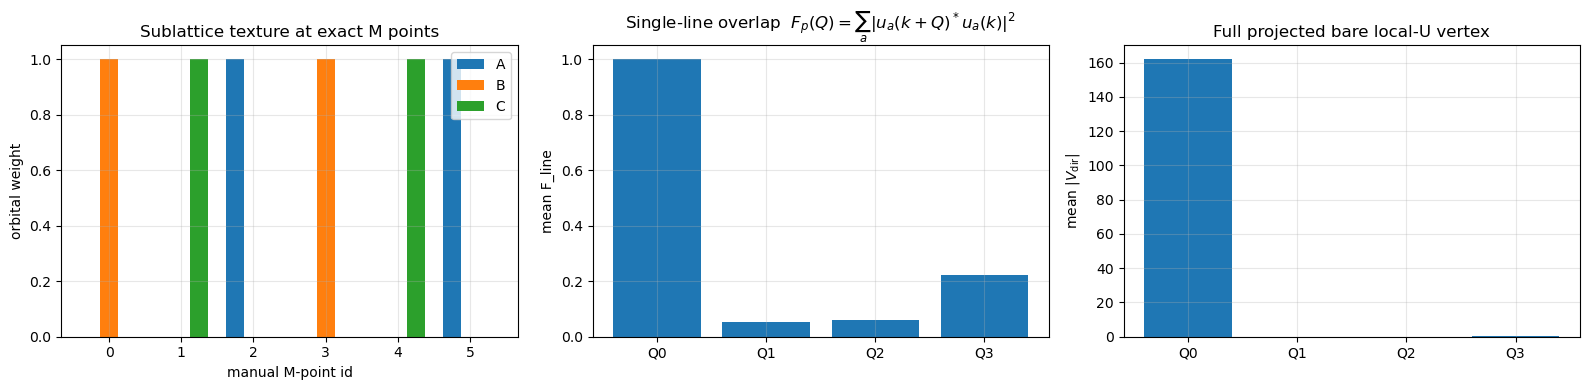


===== Q0 full projected |V_dir| matrix =====
[[  6. 240. 240.   6. 240. 240.]
 [240.   6. 240. 240.   6. 240.]
 [240. 240.   6. 240. 240.   6.]
 [  6. 240. 240.   6. 240. 240.]
 [240.   6. 240. 240.   6. 240.]
 [240. 240.   6. 240. 240.   6.]]

===== Q1 full projected |V_dir| matrix =====
[[0.       0.       0.       0.       0.       0.      ]
 [0.       0.930591 0.       0.       0.930591 0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.930591 0.       0.       0.930591 0.      ]
 [0.       0.       0.       0.       0.       0.      ]]

===== Q2 full projected |V_dir| matrix =====
[[0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       1.071054 0.       0.       1.071054]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       0.       0.       0.       0.      ]
 [0.       0.       1.071054 0.    

In [31]:
# ============================================================
# Run bare sublattice-interference test
# ============================================================

res_interference = run_sublattice_interference_test(
    U=6.0,
    V=120,
    band_index=LOCAL_BAND_INDEX,
    orbital_slice_up=UP_SLICE,
    orbital_slice_dn=DN_SLICE,
    verbose=True,
)

print_interference_tables(res_interference)
plot_sublattice_interference_result(res_interference)

# optional: inspect one Q-sector matrix in detail
for qname in ["Q0", "Q1", "Q2", "Q3"]:
    print(f"\n===== {qname} full projected |V_dir| matrix =====")
    print(np.round(res_interference["pair_data"][qname]["abs_matrix"], 6))


## 5. PI benchmark: `U=0, V=10`

Expectation from the PRL benchmark at van Hove filling:
- dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character.

If this still does **not** look PI-like, then the likely next suspects are:
- `form_factor.py`
- `kagome_order_diagnosis.py`



===== Running case: PI benchmark (U=0.0, V=10.0) =====
[DEBUG] entering step: T_old=1.50000000, dT=-8.25818085e-03
[DEBUG] leaving step: T_new=1.49174182, rhs_norm=696.9724413585882, channel_norm=5.7557244699580155, accepted_substeps=1, max_rel_update=0.28786388424232384
[DEBUG] entering step: T_old=1.49174182, dT=-8.21271582e-03
[DEBUG] leaving step: T_new=1.48352910, rhs_norm=923.3427371135338, channel_norm=13.33887597296559, accepted_substeps=1, max_rel_update=0.3792598929722047
[DEBUG] entering step: T_old=1.48352910, dT=-8.16750109e-03
[DEBUG] leaving step: T_new=1.47536160, rhs_norm=1477.11047447816, channel_norm=25.40317738357217, accepted_substeps=1, max_rel_update=0.6033778515378949
[DEBUG] entering step: T_old=1.47536160, dT=-8.12253529e-03
[DEBUG] leaving step: T_new=1.46723907, rhs_norm=2805.518158810966, channel_norm=48.191097633649264, accepted_substeps=1, max_rel_update=0.8970499991396226
[DEBUG] entering step: T_old=1.46723907, dT=-8.07781705e-03
[DEBUG] leaving step: 

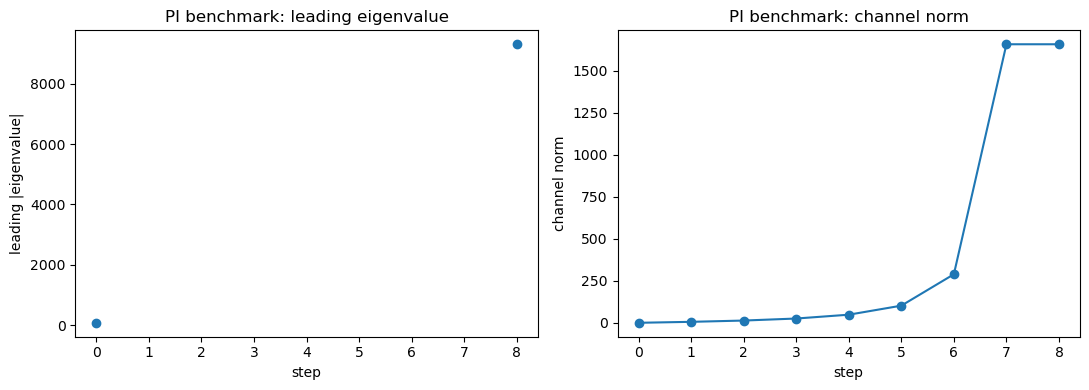

In [20]:

pi_result = run_case("PI benchmark", U=0.0, V=10.0, flow_kwargs=FLOW_KWARGS)



==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 3555.149590780289
vec.real = [ 0.70723907 -0.00757092  0.00522446  0.70685552 -0.00804659  0.00433688]
vec.abs  = [0.70723907 0.00757092 0.00522446 0.70685552 0.00804659 0.00433688]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 2990.372246504304
vec.real = [ 0.01255407 -0.63412549  0.30897717 -0.01064362  0.6378724  -0.30865172]
vec.abs  = [0.01255407 0.63412549 0.30897717 0.01064362 0.6378724  0.30865172]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 5821.181048402714
vec.real = [0.37277506 0.44090947 0.4094923  0.37244863 0.43279804 0.41583834]
vec.abs  = [0.37277506 0.44090947 0.4094923  0.37244863 0.43279804 0.41583834]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 8945.768270906441
vec.real = [0.39814162 0.42997657 0.40139207 0.390358   0.42031472 0.40797546]
vec.abs  = [0.39814162 0.42997657 0.40139207 0.390358   0.42031472 0.40797546]
===== Final-state diagnosis across all Q =====

===== Q[0] = [0. 0.] =====

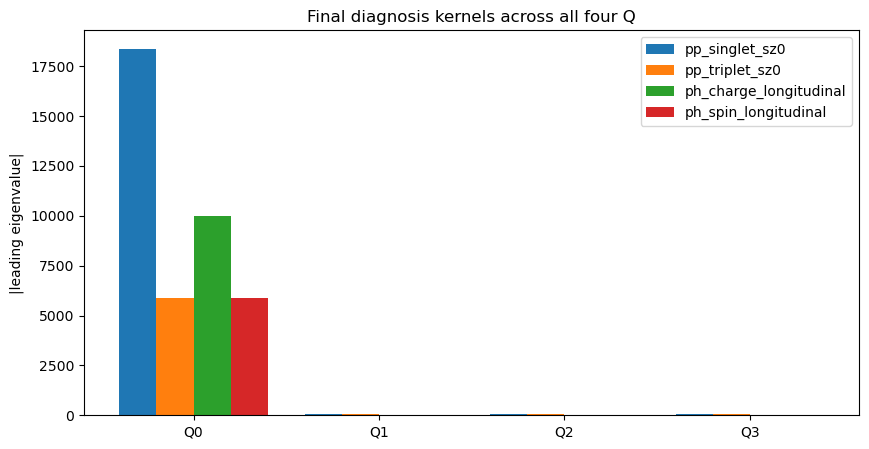


==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 18379.174893856598
vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
vec.abs  = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5888.053764214001
vec.real = [ 7.07111730e-01  1.55302902e-06  2.37187541e-04 -7.07101753e-01
 -1.55214591e-06 -2.37475159e-04]
vec.abs  = [7.07111730e-01 1.55302902e-06 2.37187541e-04 7.07101753e-01
 1.55214591e-06 2.37475159e-04]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 10008.572110478563
vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
vec.abs  = [7.07060035e-01 3.21832580e-04 2.19984888e-04 7.07153310e-01
 3.21513864e-04 2.19953149e-04]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 5900.842538485015
vec.real = [-7.07066422e-01 -3.75107687e-04  4.56785480e-04  7.07146644e-01
  3.75225156e-04 -4.57017143e-04]
vec.abs  = [7.070664

In [21]:

solver = pi_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]

channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = fm_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

## 6. Compact side-by-side summary

In [ ]:

def compact_case_summary(result):
    rec = result["final_record"]
    return {
        "case": result["case_name"],
        "U": result["U"],
        "V": result["V"],
        "leading_channel": rec.leading_channel_name,
        "leading_order": rec.leading_order_label,
        "leading_abs_eval": rec.leading_eigenvalue_abs,
        "channel_norm": rec.channel_norm,
        "instability": rec.instability,
        "instability_reason": rec.instability_reason,
    }

summary = [
    compact_case_summary(fm_result),
    compact_case_summary(pi_result),
]

for row in summary:
    pprint(row)



## 7. Optional: inspect the raw diagnosis payloads

This is useful when:
- the FM case is reasonable but the PI case is not
- or the final `leading_order_label` is too coarse / ambiguous


In [ ]:

print("===== FM diagnosis payload =====")
pprint(fm_result["final_record"].diagnosis_payload)

print("\n===== PI diagnosis payload =====")
pprint(pi_result["final_record"].diagnosis_payload)



## 8. What to conclude from the outcomes

### If you get:
- `U=6, V=0` → FM-like
- `U=0, V=10` → PI-like

then the corrected `channels.py` + `frg_flow.py` have likely fixed the main bug, and the whole pipeline is much closer to the target PRL behavior.

### If you get:
- FM benchmark looks reasonable
- PI benchmark still does **not** become PI-like

then the next things to debug are likely:
1. **form-factor projection**
2. **PI degeneracy handling**
3. **kagome-specific diagnosis templates**

and only after that would I go back and seriously suspect the one-loop kernel again.
